# STEP 1 — Diagnosis & Cleaning + EDA + Leakage audit

5 churn datasets are processed **independently**; sets are never merged, outputs
are separate per set. In this step **no encoding is done** (categoricals are left raw)
and **no modeling is done**. The heavy logic is in the `src/` functions; this script
only calls them in order (can be run cell by cell with Shift+Enter).

In [1]:
# Common setup: imports + seed(42) + shared figure style.
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml not found — run from the repo root")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

from src import clean as clean_mod
from src import config as cfg
from src import eda as eda_mod
from src import leakage as leak_mod
from src import load as load_mod
from src import plotstyle as ps
from src import strings as S

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

CIKTI = []  # console summary; written under outputs/logs/ at the end


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. Pre-check and profile
Do the files exist, does the actual profile (rows/columns/churn) match the reference values?

In [2]:
yaz(S.MSG["bolum"].format(ad="PRE-CHECK & PROFILE"))
_eksik = [d["file"] for d in cfg.DATASETS.values() if not (cfg.RAW / d["file"]).exists()]
if not (cfg.HOLDOUT / cfg.HOLDOUT_DOSYA).exists():
    _eksik.append(cfg.HOLDOUT_DOSYA)
assert not _eksik, S.MSG["on_kontrol_eksik"].format(dosya=", ".join(_eksik))

etiketli = load_mod.yukle_etiketli()
holdout = load_mod.yukle_holdout()

for key, d in cfg.DATASETS.items():
    info = etiketli[key]
    churn = 100 * info["df"]["churn"].mean()
    r = cfg.REFERANS[key]
    assert info["raw_shape"][0] == r[0], f"{key}: row {info['raw_shape'][0]} != ref {r[0]}"
    yaz(S.MSG["profil_satiri"].format(
        set=key, satir=info["raw_shape"][0], sutun=info["raw_shape"][1],
        churn=churn, ref=f"{r[2]}%", hedef=d["target"]))
    if info["dropped"]:
        yaz("    " + S.MSG["id_dusuruldu"].format(set=key, kolonlar=info["dropped"]))

# unlabeled holdout validation
assert holdout["df"]["churn"].isna().all(), "cell2cell_test appears to be labeled"
yaz(f"{'cell2cell_test':11s} {holdout['raw_shape'][0]:>6d}x{holdout['raw_shape'][1]:<3d}  UNLABELED holdout")
yaz(S.MSG["on_kontrol_ok"].format(n=len(cfg.DATASETS)))

===== PRE-CHECK & PROFILE =====


telco         7043x21   churn= 26.5%  (ref 26.5%)  target='Churn'
    telco: dropped identifier column(s) -> ['customerID']
cell2cell    51047x58   churn= 28.8%  (ref 28.8%)  target='Churn'
    cell2cell: dropped identifier column(s) -> ['CustomerID']
ecommerce     3941x11   churn= 17.1%  (ref 17.1%)  target='Churn'
iranian       3150x14   churn= 15.7%  (ref 15.7%)  target='Churn'
bank         10000x14   churn= 20.4%  (ref 20.4%)  target='Exited'
    bank: dropped identifier column(s) -> ['RowNumber', 'CustomerId', 'Surname']
cell2cell_test  20000x58   UNLABELED holdout
Pre-check: 5 datasets + 1 unlabeled holdout found, consistent with reference profiles.


## 2. Cleaning
Only safe operations per set (missing-value imputation + type correction). Output:
`data/processed/<set>_clean.csv`. The cell2cell holdout is imputed with train statistics.

In [3]:
yaz(S.MSG["bolum"].format(ad="CLEANING"))
processed, temizlik_log = clean_mod.temizle_hepsi(etiketli, holdout)
for s, kolon, islem, detay in temizlik_log:
    yaz(S.MSG["temizlik_satiri"].format(set=s, kolon=kolon, islem=f"{islem} | {detay}"))

# temizlik_log -> CSV (Turkish headers)
clean_df = pd.DataFrame(temizlik_log, columns=[
    S.KOLON["veri_seti"], S.KOLON["kolon"], S.KOLON["islem"], S.KOLON["detay"]])
clean_df.to_csv(cfg.TABLES / "cleaning_log.csv", index=False)
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "cleaning_log.csv"))

===== CLEANING =====


telco       TotalCharges                 text -> numeric | 11 blank; tenure=0 -> 0 (11 rows); remaining 0 kept as NaN
cell2cell   -                            missing kept | 3515 cells left as NaN, imputed within fold
cell2cell_test -                            missing kept | 1304 cells left as NaN, imputed within fold
ecommerce   -                            missing kept | 576 cells left as NaN, imputed within fold
bank        -                            clean | no missing, untouched
iranian     -                            clean | no missing, untouched
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/tables/cleaning_log.csv


## 3. Leakage audit
For each labeled set, univariate churn AUC per feature; ≥ 0.90 SUSPICIOUS.
**Report only** — no column is dropped, the decision is left to the user.

In [4]:
yaz(S.MSG["bolum"].format(ad="LEAKAGE AUDIT"))
leak_df = leak_mod.denetle_hepsi(processed)
supheli = leak_df[leak_df[S.KOLON["bayrak"]] == S.BAYRAK_SUPHELI]
if len(supheli):
    for _, r in supheli.iterrows():
        yaz(S.MSG["leakage_supheli"].format(
            set=r[S.KOLON["veri_seti"]], ozellik=r[S.KOLON["ozellik"]],
            auc=r[S.KOLON["tekil_auc"]], aksiyon=r[S.KOLON["aksiyon"]]))
else:
    yaz("No suspicious (AUC ≥ 0.90) feature found.")
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "leakage_audit.csv"))

===== LEAKAGE AUDIT =====


No suspicious (AUC ≥ 0.90) feature found.
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/tables/leakage_audit.csv


## 4. EDA figures and overview
For each labeled set, 5 figures + an overview table under `outputs/figures/<set>/`.

===== EDA FIGURES =====


telco: 5 figures -> /Users/emrahfidan/Desktop/makale-2/outputs/figures/telco


cell2cell: 5 figures -> /Users/emrahfidan/Desktop/makale-2/outputs/figures/cell2cell
    (high cardinality, skipped in categorical figure: ['ServiceArea', 'HandsetPrice'])


ecommerce: 5 figures -> /Users/emrahfidan/Desktop/makale-2/outputs/figures/ecommerce


iranian: 5 figures -> /Users/emrahfidan/Desktop/makale-2/outputs/figures/iranian


/Users/emrahfidan/Desktop/makale-2/src/eda.py:36: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 4))


bank: 5 figures -> /Users/emrahfidan/Desktop/makale-2/outputs/figures/bank
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/tables/dataset_overview.csv
       Dataset    Sector  Rows  Columns  Churn %  Missing (before)  Missing (after)                                                   Note
         telco   telecom  7043       21     26.5                 0                0                                                       
     cell2cell   telecom 51047       58     28.8              3515             3515                                                       
     ecommerce ecommerce  3941       11     17.1               576              576                                                       
       iranian   telecom  3150       14     15.7                 0                0                                                       
          bank   banking 10000       14     20.4                 0                0                                                       
cell2cell_tes

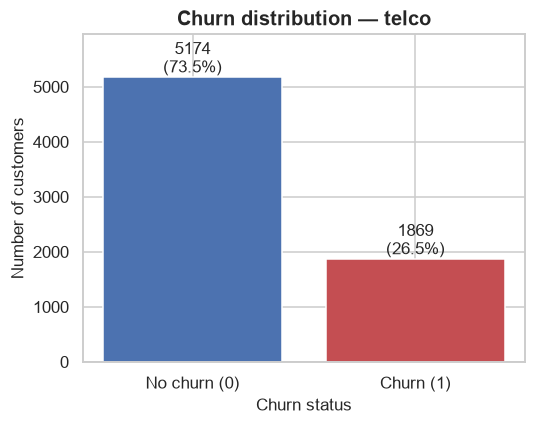

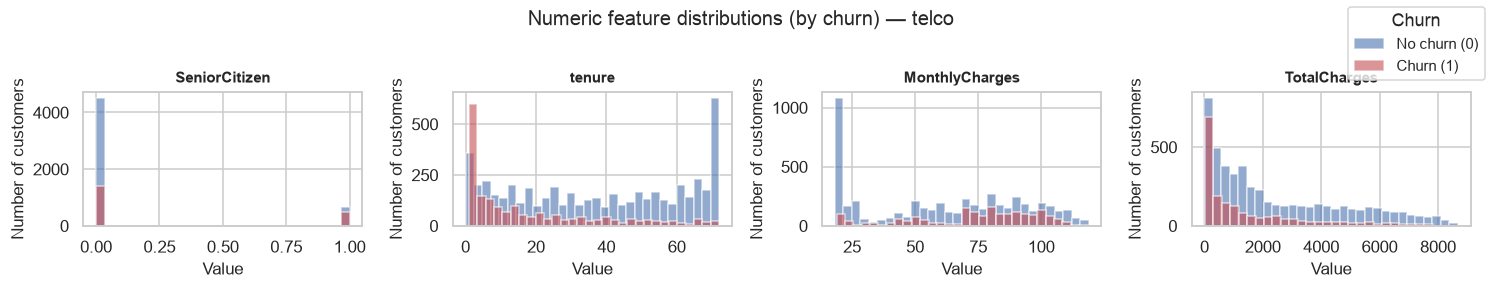

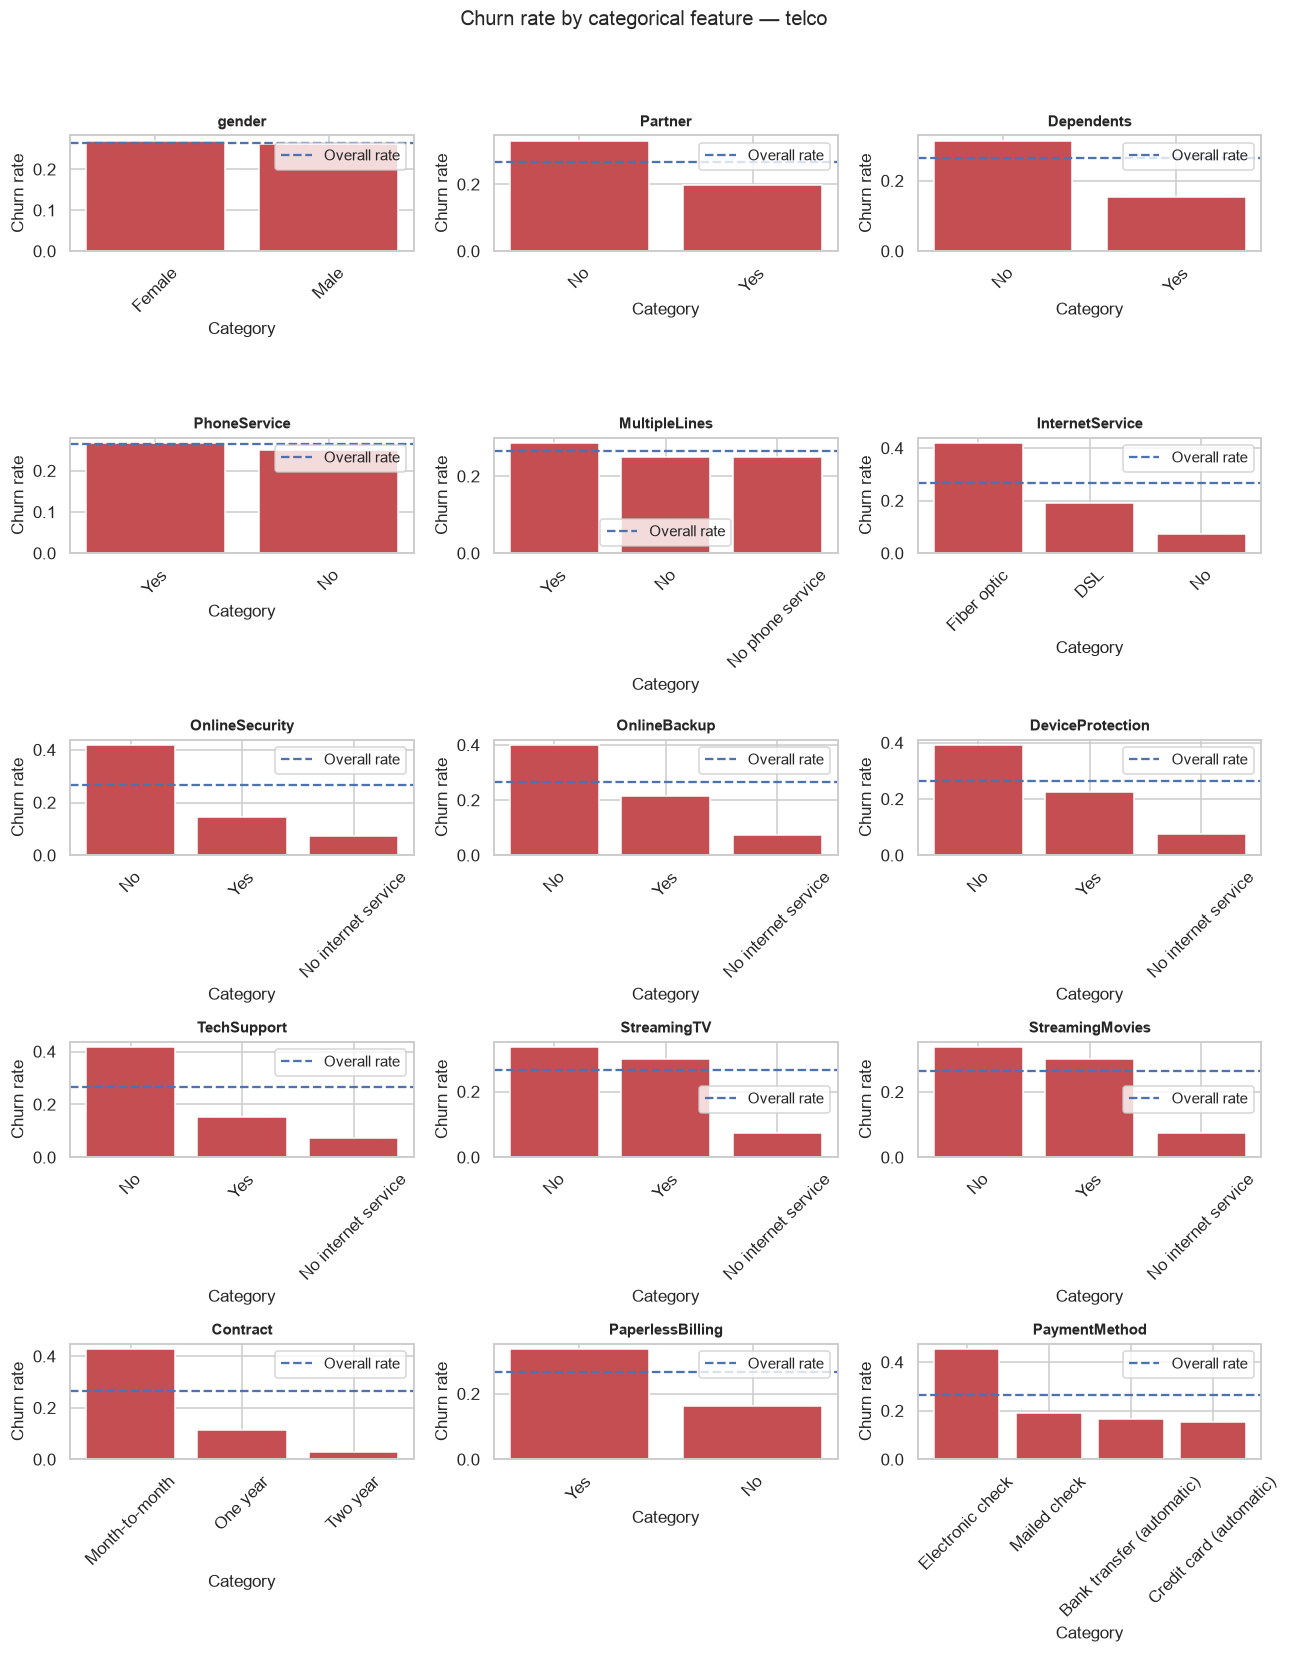

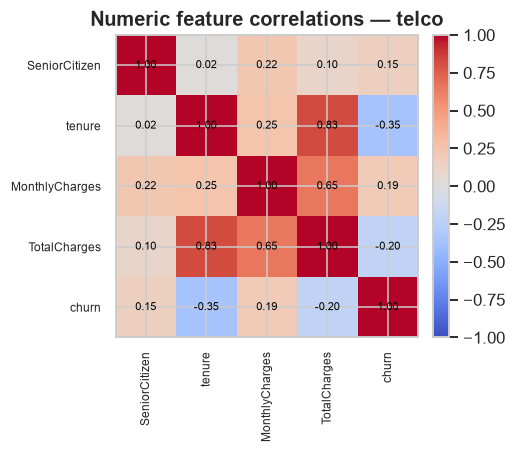

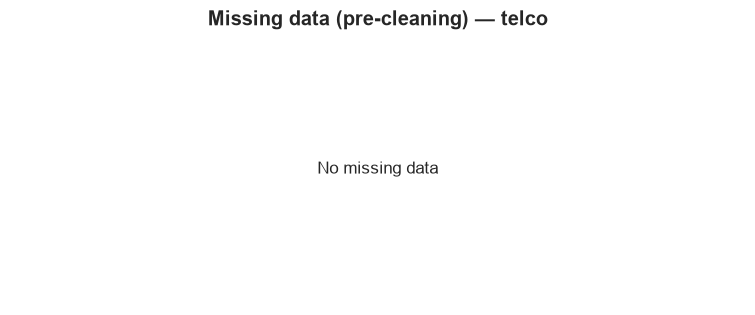

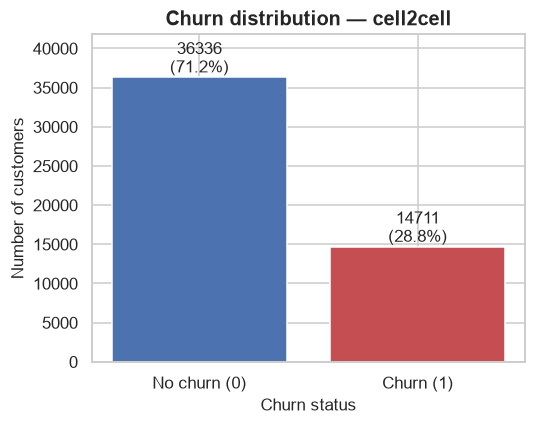

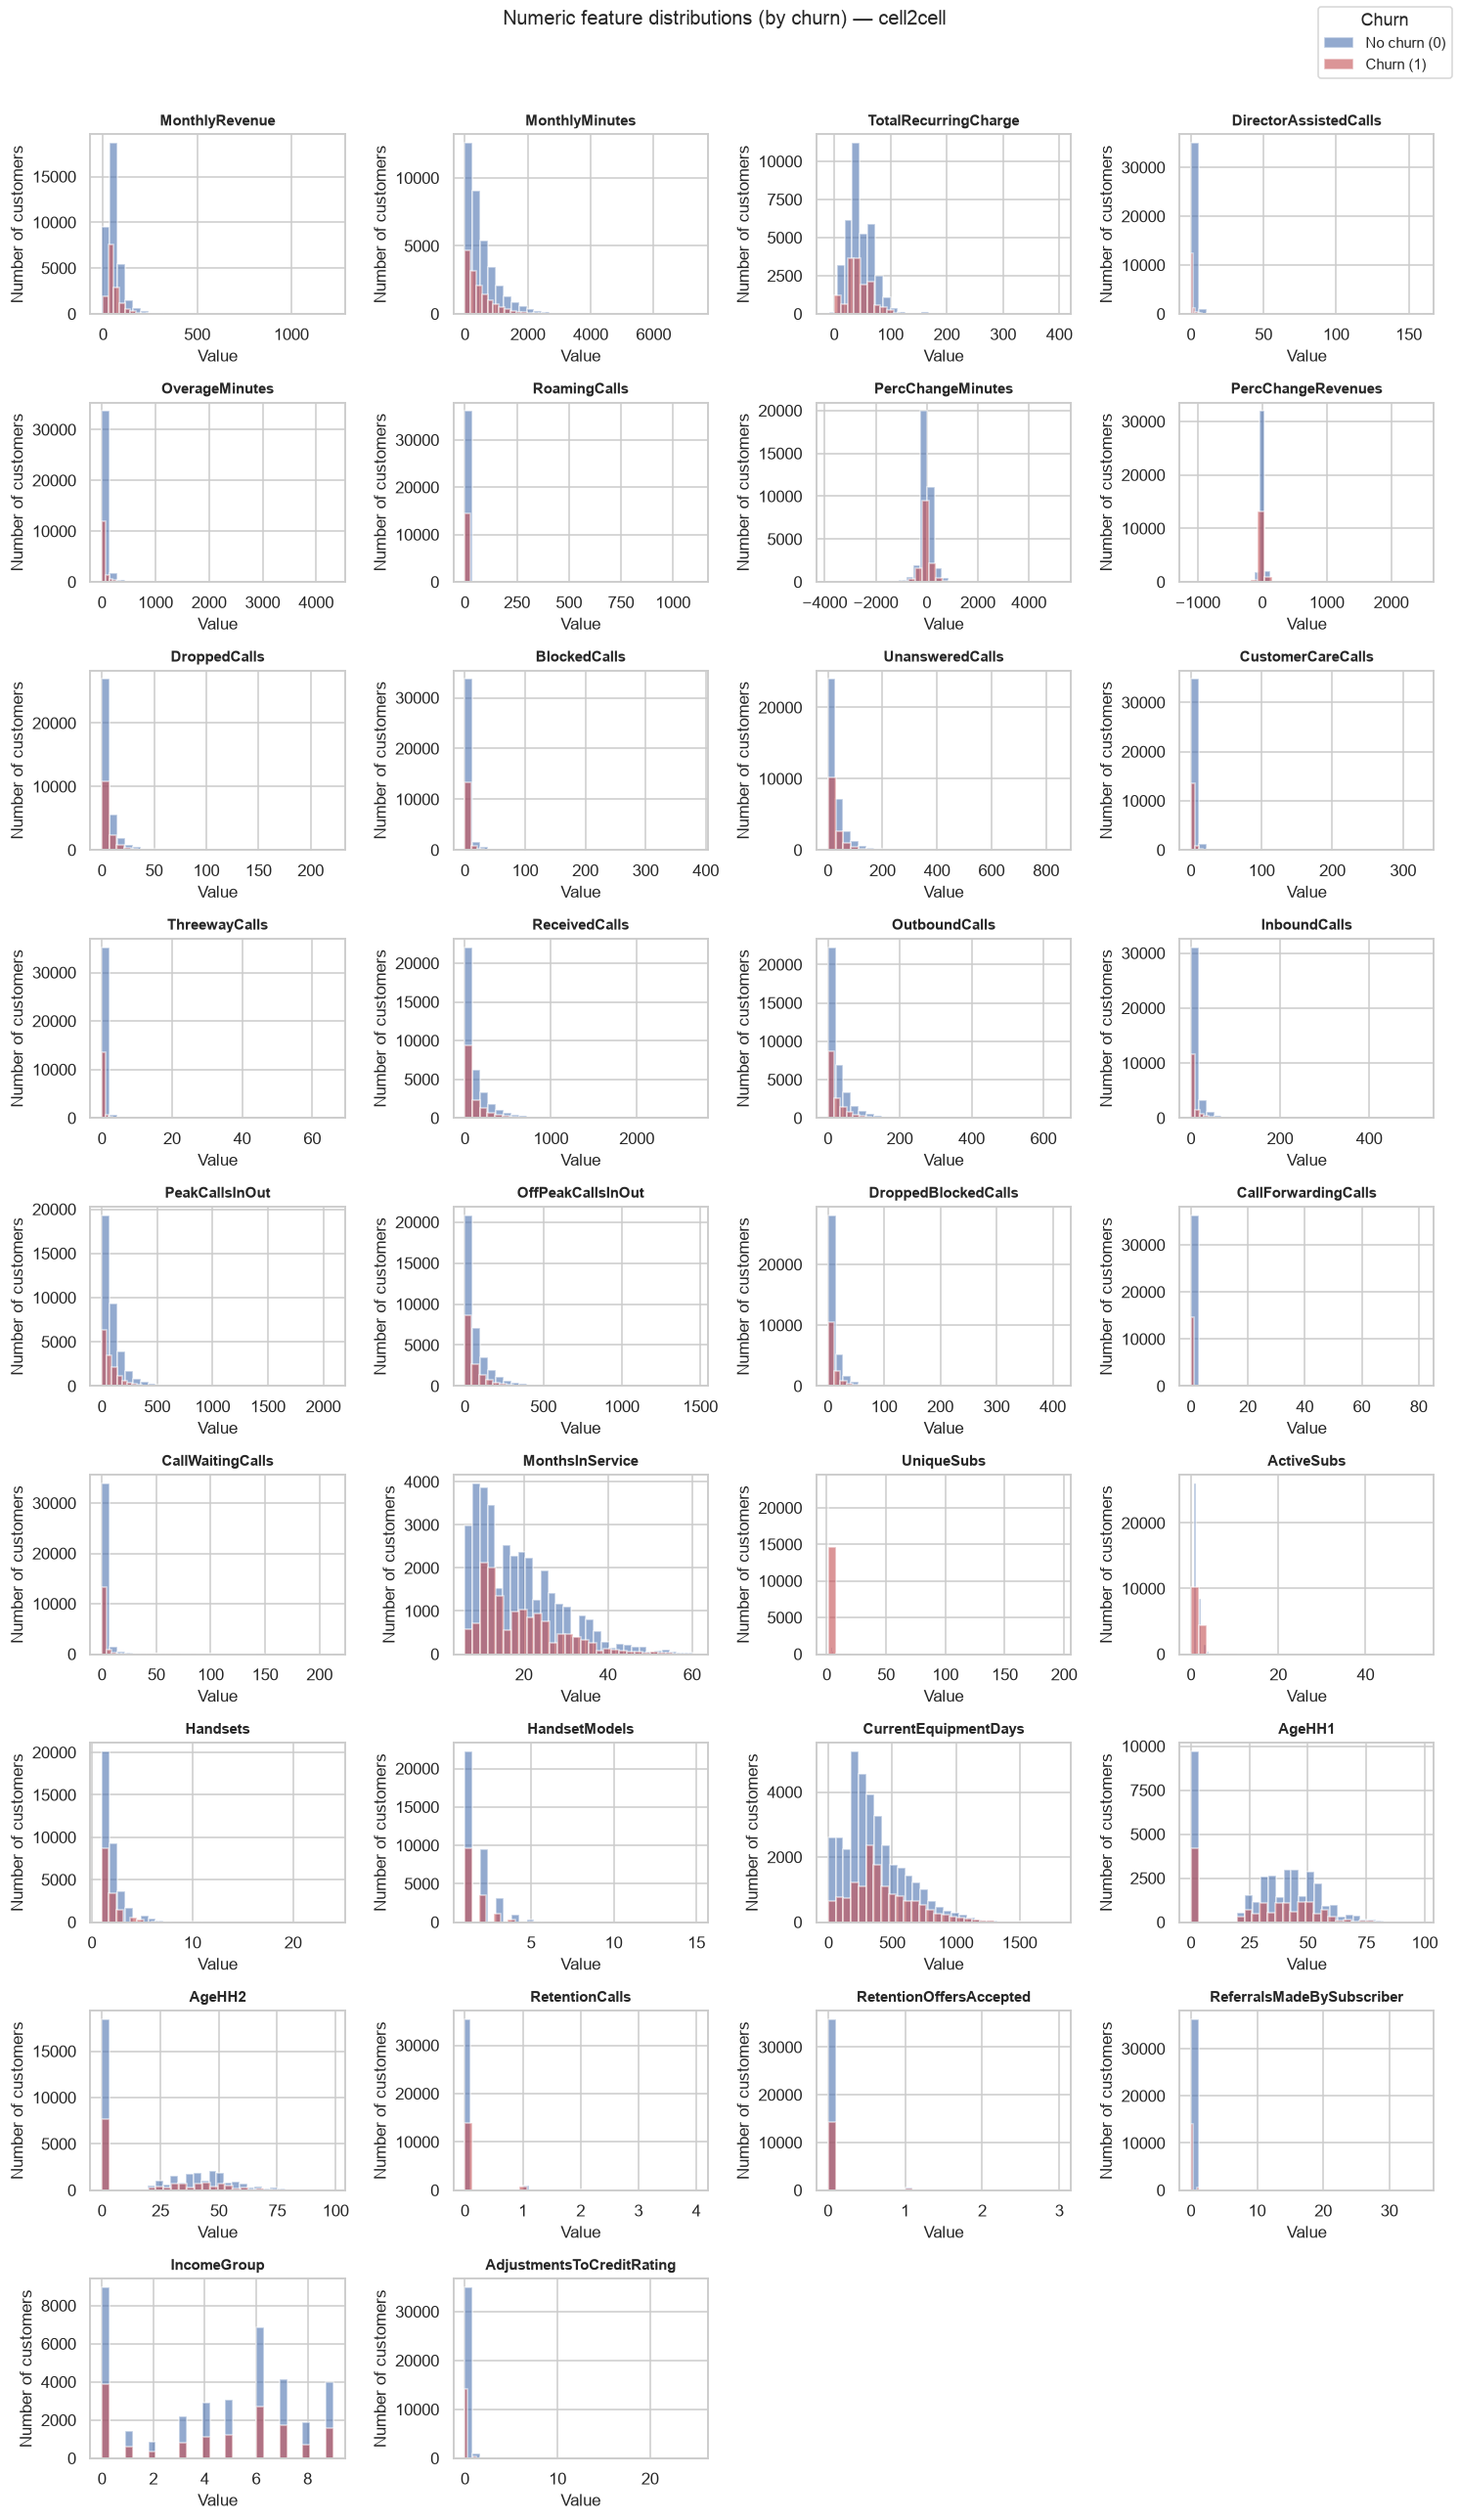

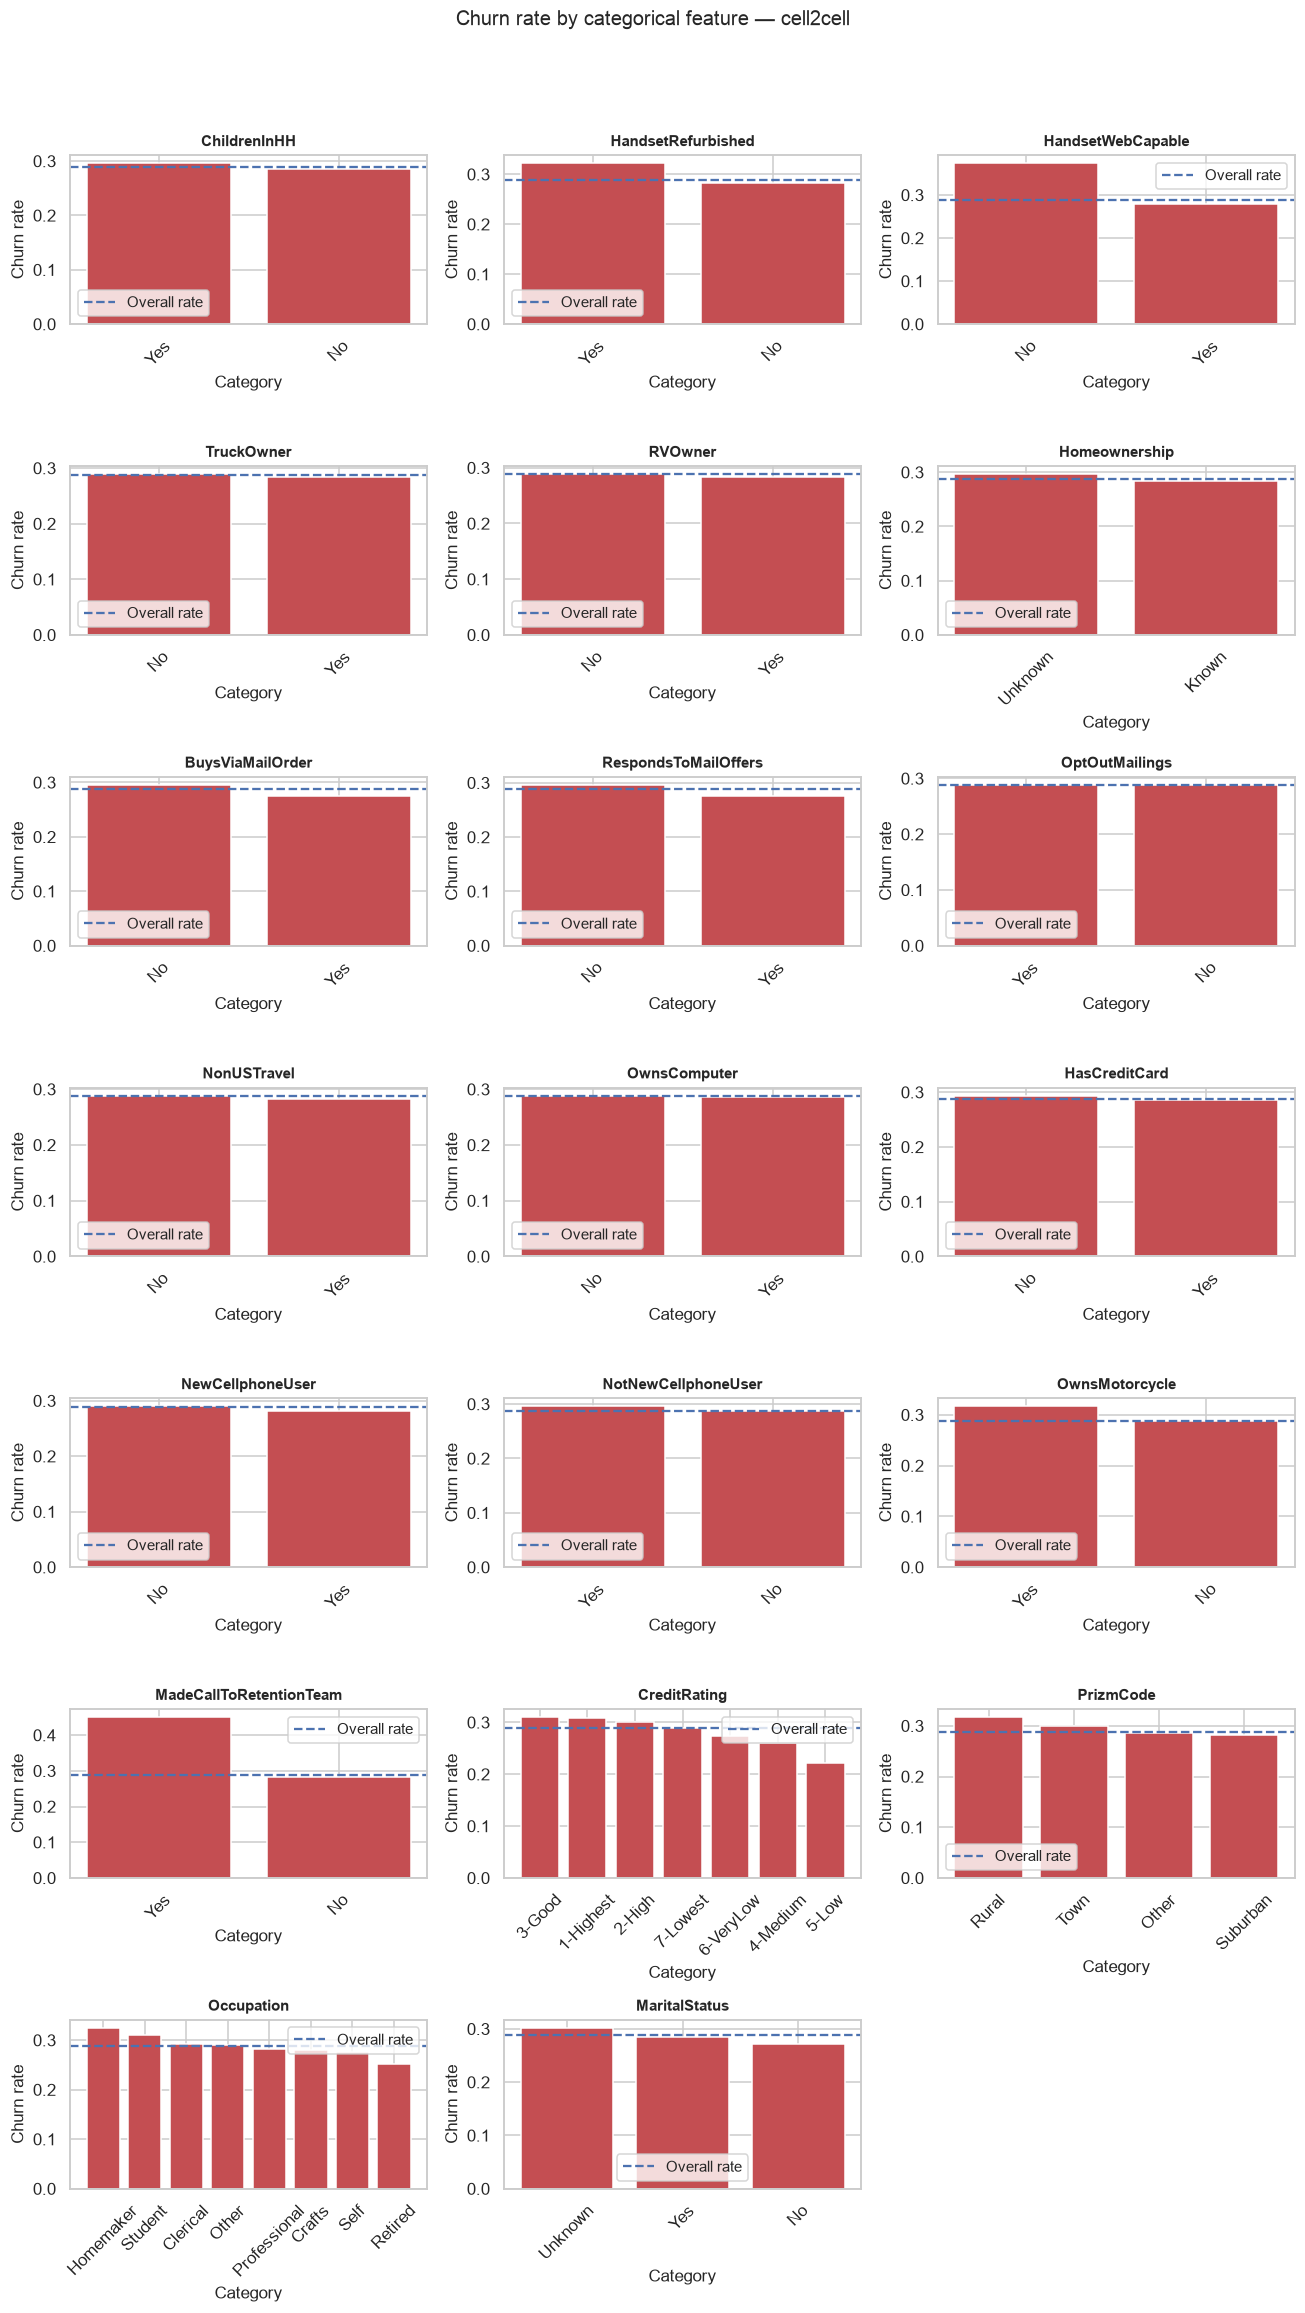

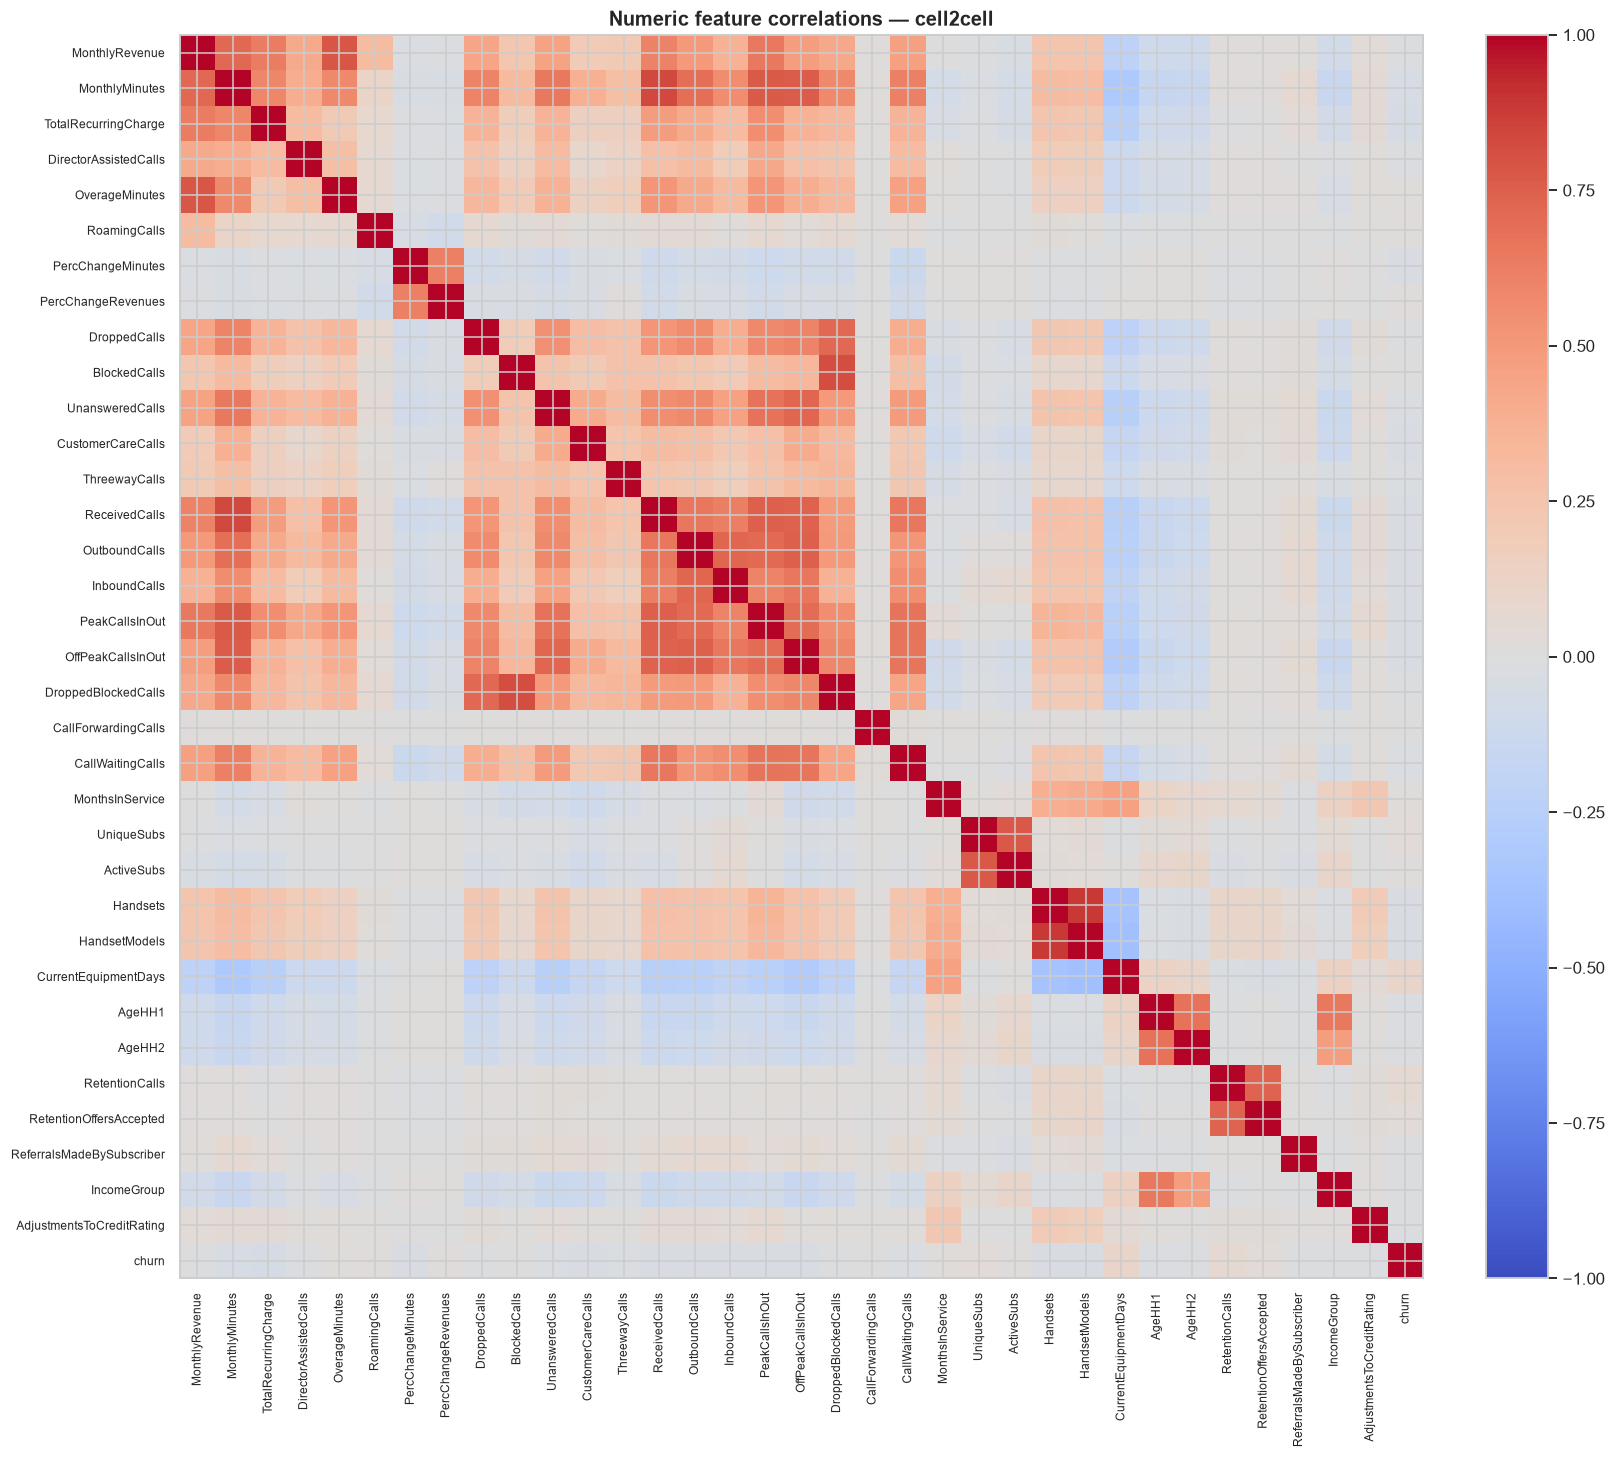

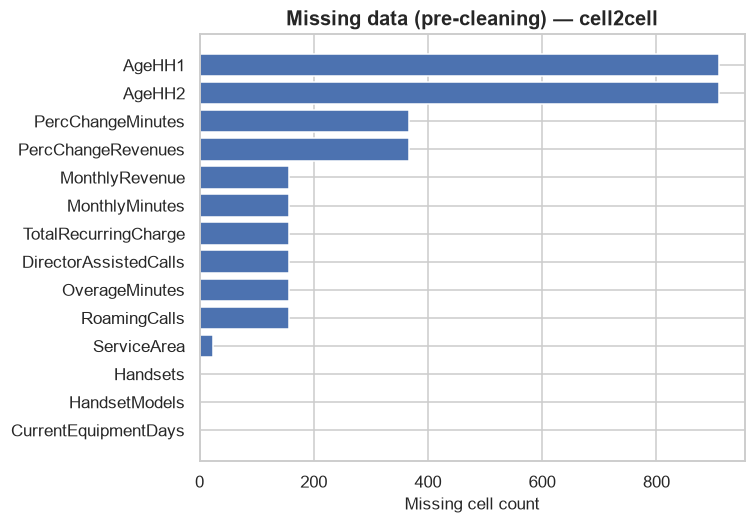

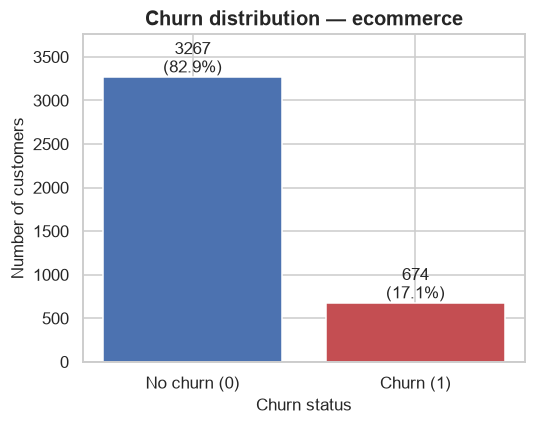

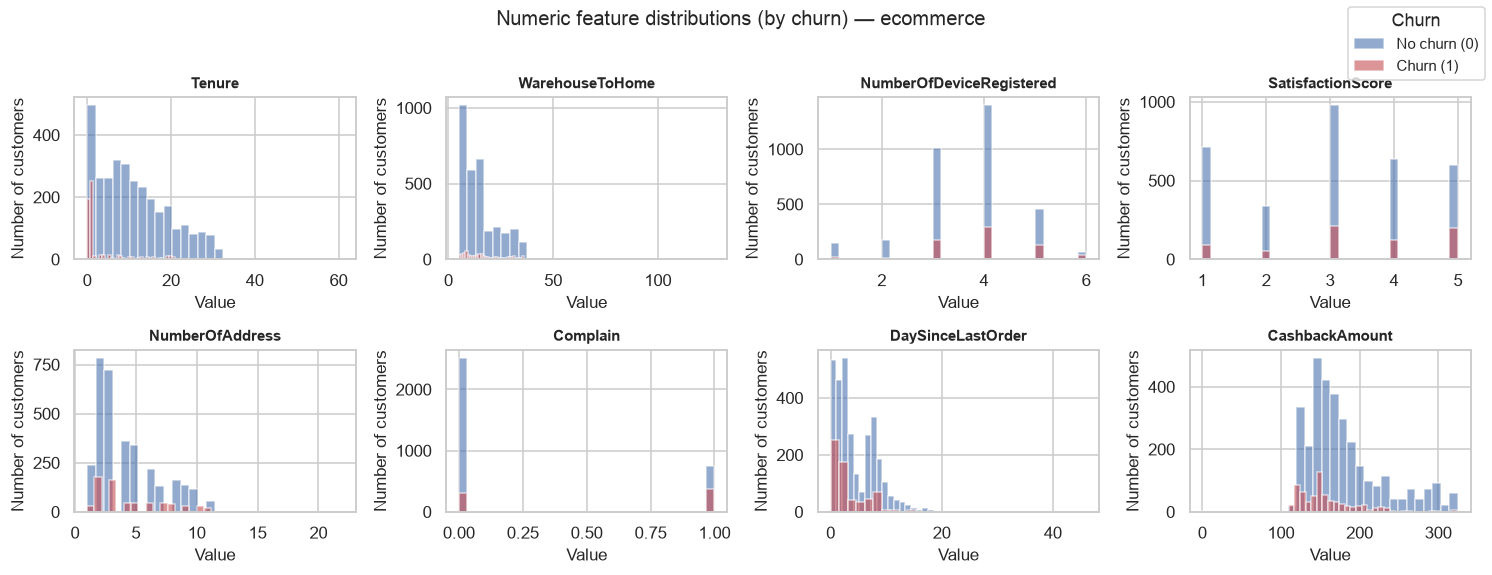

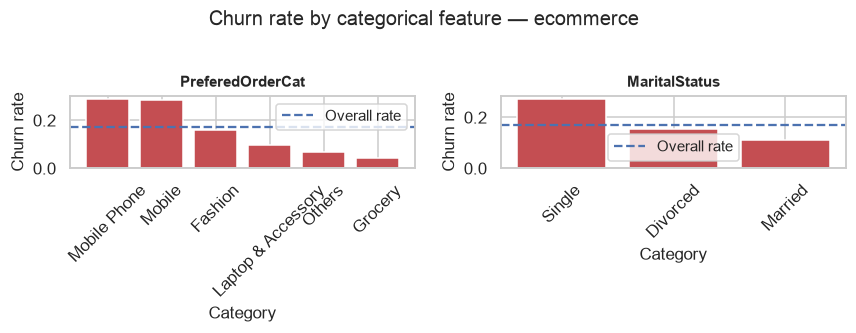

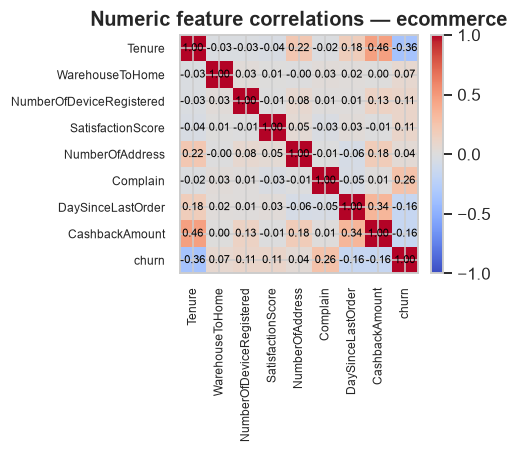

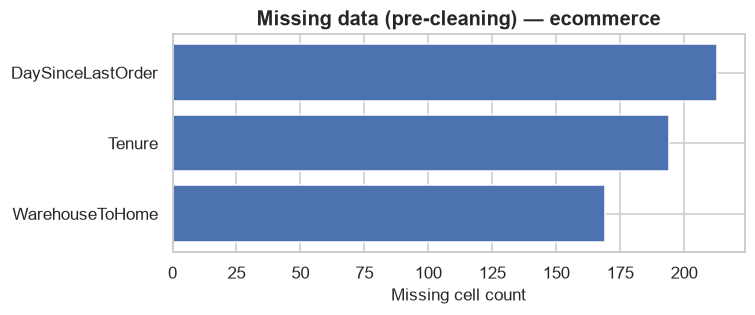

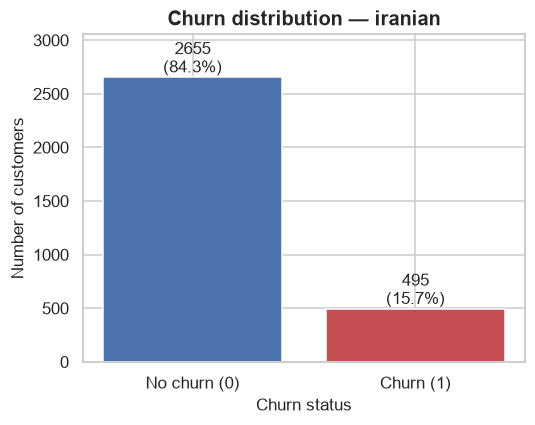

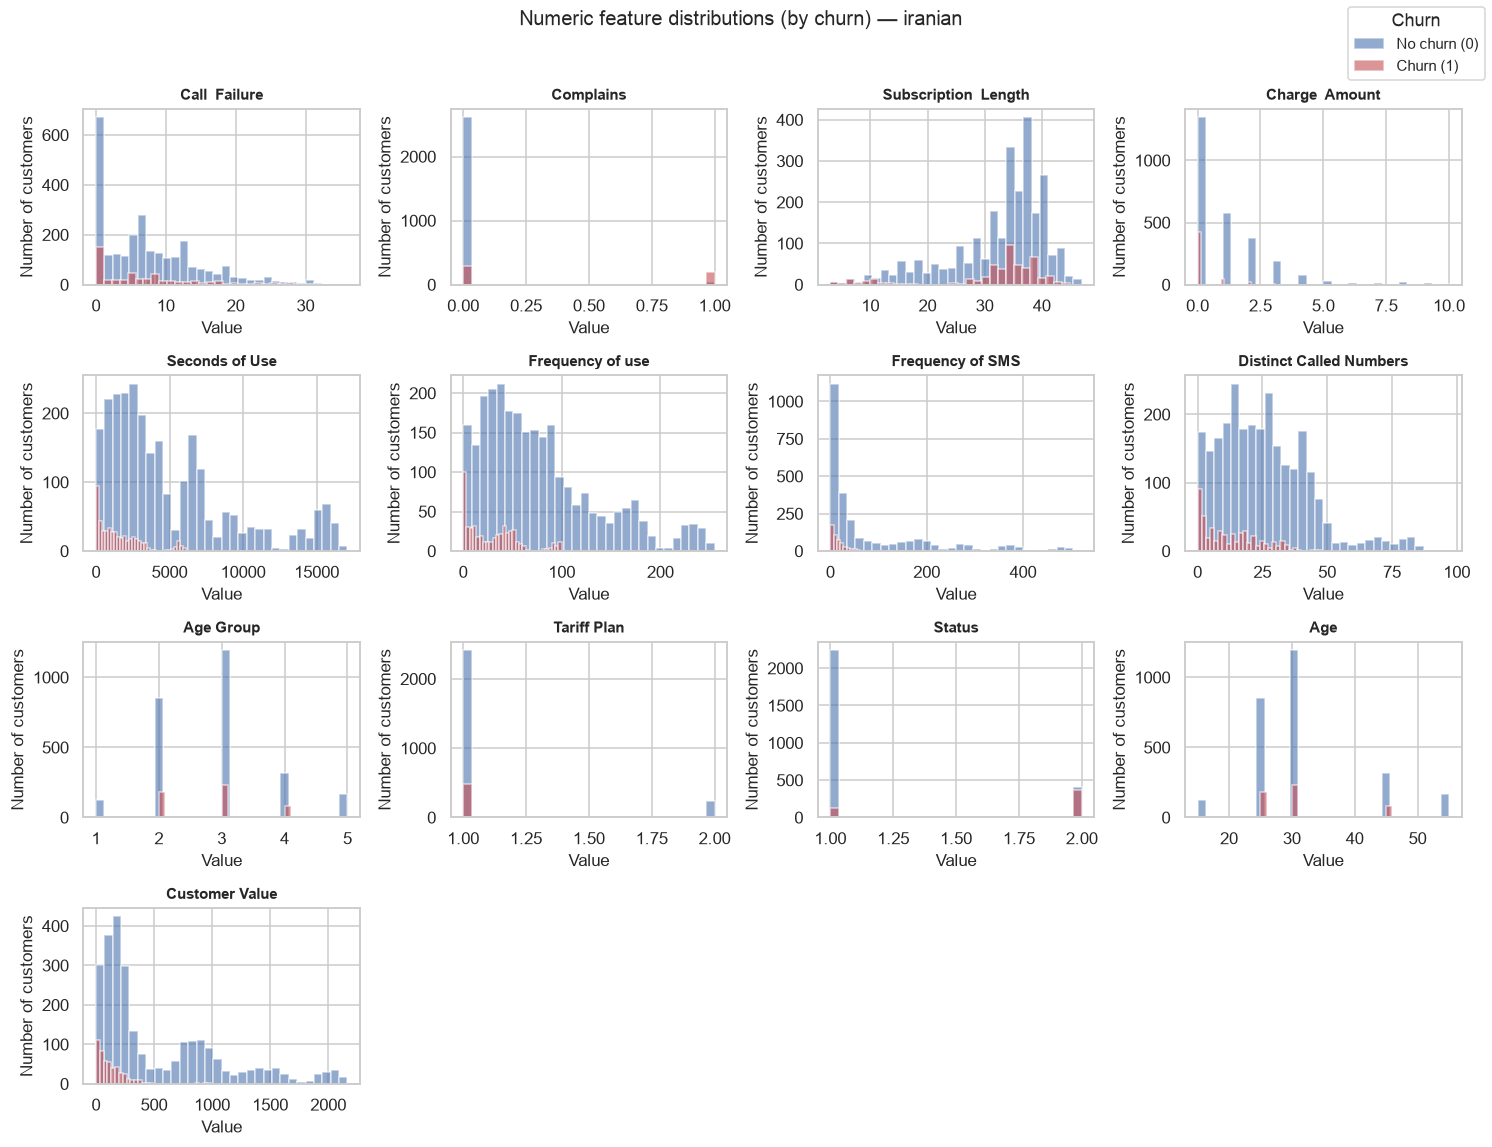

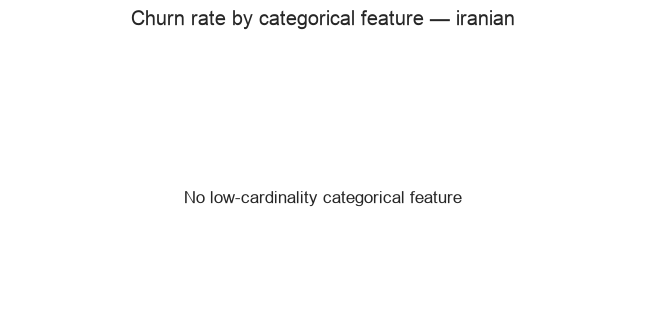

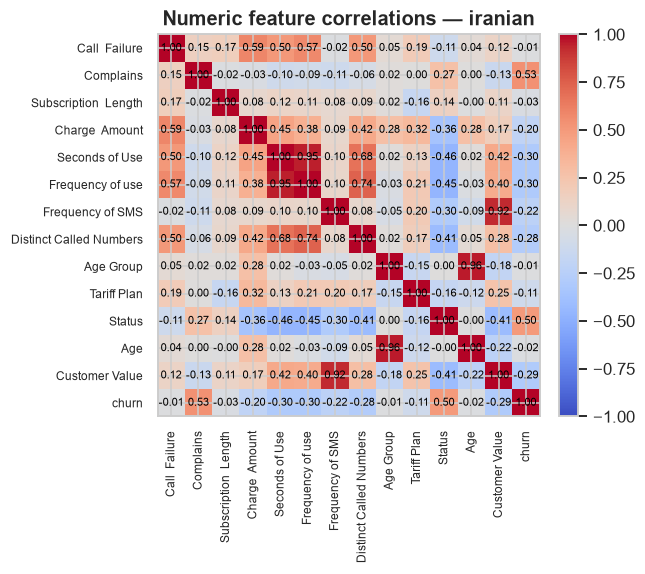

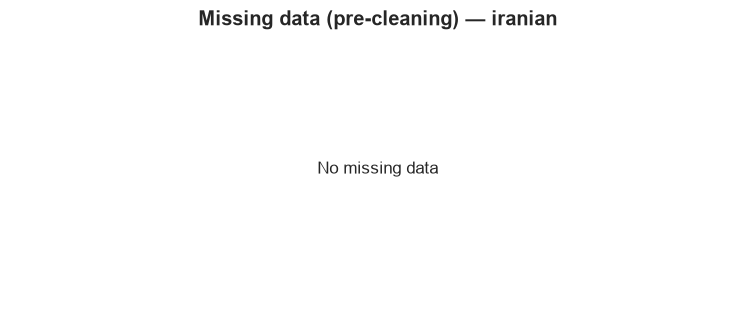

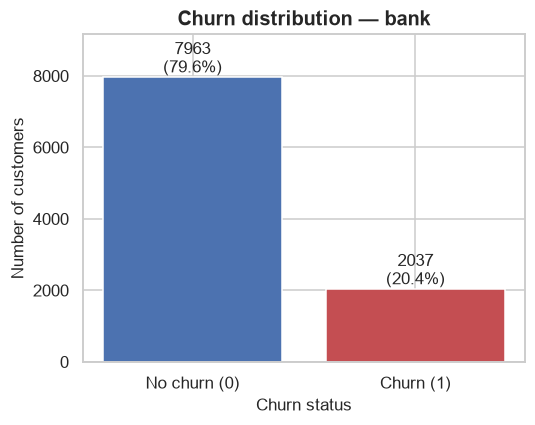

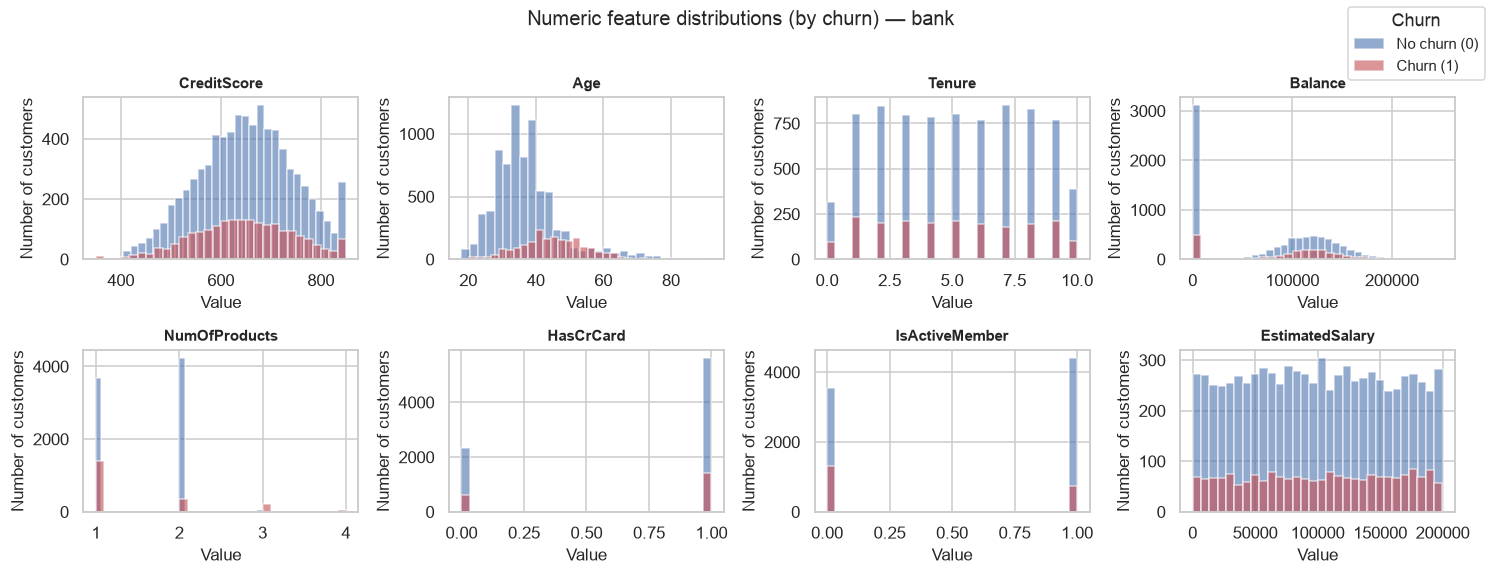

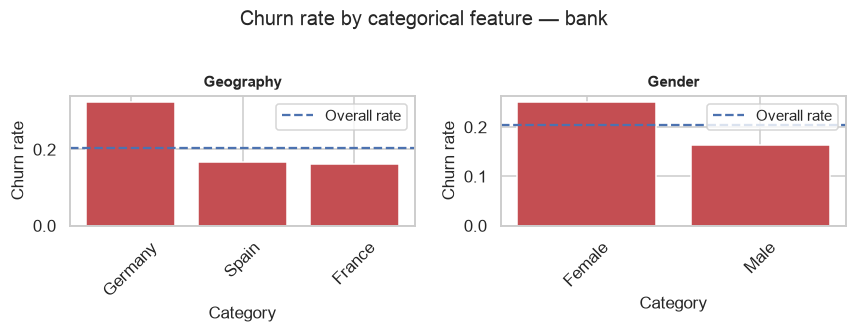

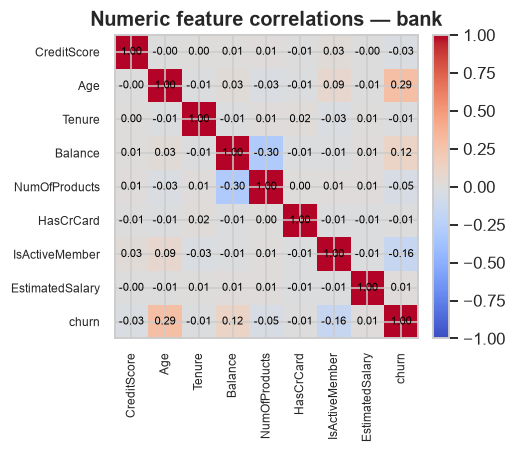

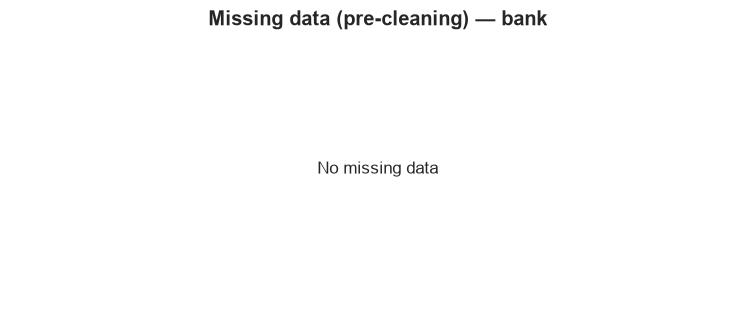

In [5]:
yaz(S.MSG["bolum"].format(ad="EDA FIGURES"))
for key in cfg.DATASETS:
    yollar, atlanan = eda_mod.figurler_set(key, processed[key], etiketli[key]["df"])
    yaz(f"{key}: {len(yollar)} figures -> {cfg.FIGURES / key}")
    if atlanan:
        yaz(f"    (high cardinality, skipped in categorical figure: {atlanan})")

overview = eda_mod.genel_bakis(etiketli, processed, holdout)
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "dataset_overview.csv"))
yaz(overview.to_string(index=False))

## 5. Summary
The console summary is also written under `outputs/logs/`. The drop decision (leakage)
was left to the user; no modeling was done.

In [6]:
yaz(S.MSG["bolum"].format(ad="SUMMARY"))
yaz(f"Processed labeled sets: {len(cfg.DATASETS)} | unlabeled holdout: 1")
yaz(f"Cleaning decision rows: {len(temizlik_log)} | suspicious features: {len(supheli)}")
yaz(S.MSG["bitti"])

_log_yol = cfg.LOGS / "adim1_ozet.log"
_log_yol.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log_yol))

===== SUMMARY =====
Processed labeled sets: 5 | unlabeled holdout: 1
Cleaning decision rows: 6 | suspicious features: 0
STEP 1 complete. Column-drop decision left to the user (leakage). No modeling performed.
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/logs/adim1_ozet.log
